# Title: California Housing Price Prediction 
`Author:` [Md Mamun Rasid Prodhan](https://www.linkedin.com/in/mamun-rasid-prodhan/)


# Meta Data (About Dataset)
## Context
- Number of Instances (rows): 20,640

- Number of Features (columns): 8 numeric predictors

- Target Variable: Median house value (in units of $100,000)

- Source: Derived from the 1990 U.S. Census, originally from the StatLib repository

- Granularity: Each row represents a census block group (smallest geographic unit published by the U.S. Census Bureau, typically 600–3,000 people)

## Content
## Column Descriptions:

1. `MedInc`: Median income in block group
2. `HouseAge`: Median house age in block group
3. `AveRooms`: Average number of rooms per household
4. `AveBedrms`: Average number of bedrooms per household
5. `Population`: Block group population
6. `AveOccup`: Average number of household members
7. `Latitude`: Block group latitude
8. `Longitude`:	Block group longitude
9. `Target (MedHouseVal)`:	Median house value in $100,000s

# Aims and Objective:
The aim of this study is to analyze the California Housing dataset (derived from the 1990 U.S. Census) to develop predictive models for estimating median house values across different block groups. By leveraging the dataset’s eight socio‑economic and geographic features—such as median income, house age, average rooms, population, and location coordinates—the objective is to:

- Understand the relationship between demographic and housing characteristics and property values.

- Apply regression techniques to predict housing prices based on available features.

- Evaluate model performance using metrics such as R² score and Mean Squared Error (MSE).

### import The required libreary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

### import boston house price dataset

In [2]:
df = fetch_california_housing()

In [3]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

#### convert the data to a pandas dataframe

In [4]:
# load the data to a pandas data frame 
house_price_df = pd.DataFrame(df.data, columns = df.feature_names)
house_price = pd.DataFrame(df.target, columns = df.target_names)
house_price_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
house_price.head(2)

,MedHouseVal
0,4.526
1,3.585


In [6]:
house_price_df['price'] = house_price

In [7]:
house_price_df.head(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22,3.585


# Check for the missing Values

In [8]:
house_price_df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

### Statistical Measure of the data 

In [9]:
house_price_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Understanding the correlation between various features in the dataset 

There are two type of correlation 
1. positive correlation 
2. negetive correlation 

In [10]:
correlation = house_price_df.corr()

### Constructin heatmap to understand the correlation 

<Axes: >

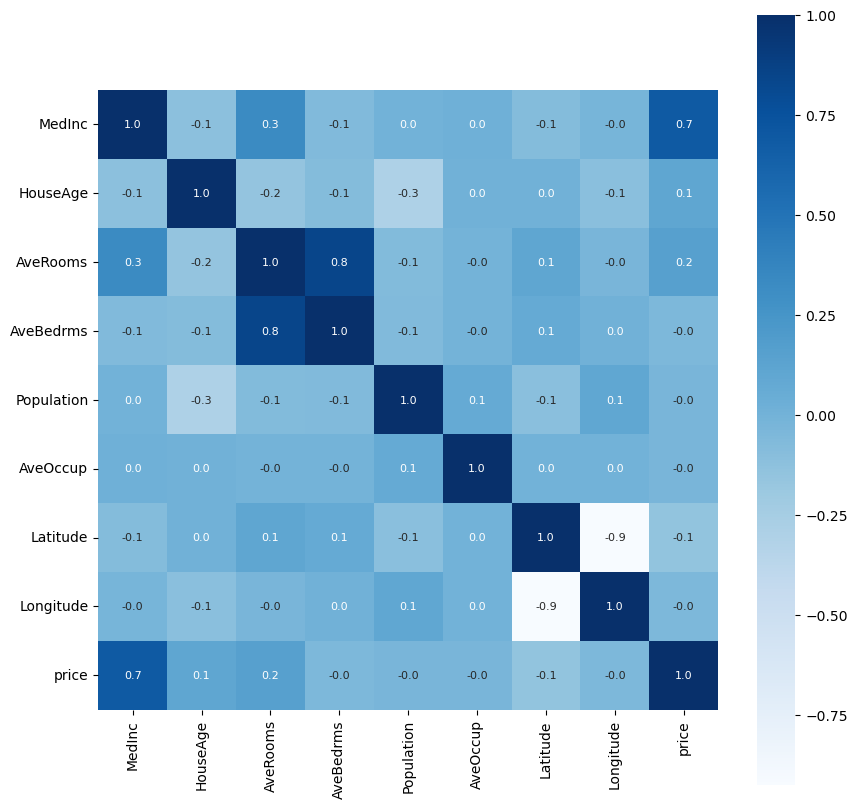

In [11]:
plt.figure(figsize = (10,10))
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot = True, annot_kws = {'size':8}, cmap = 'Blues')

# Spliting the data and the target

In [12]:
x = house_price_df.drop(['price'],axis = 1)
y = house_price_df['price']

In [13]:
print(x)
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

### split the data for train test

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [15]:
x_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [16]:
print(x_train.shape, x_test.shape)

(16512, 8) (4128, 8)


## Model Training 

#### XGBoost Regressor

In [17]:
# loding the model
model = XGBRegressor()

In [18]:
# Traning the model with X_train
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Evalute the model

Prediction on training data 

In [20]:
y_predict = model.predict(x_test)

In [21]:
y_predict

array([0.5944522 , 0.7841187 , 5.1981163 , ..., 5.058281  , 0.76106036,
       1.8375903 ], dtype=float32)

In [23]:
# R squar error
r_score = metrics.r2_score(y_test, y_predict)
r_score

0.8301370561019205

In [24]:
# Mean Absulute error 
mea = metrics.mean_absolute_error(y_test, y_predict)
mea

0.30957335413783094

## visualizing the actual price and predicted price 

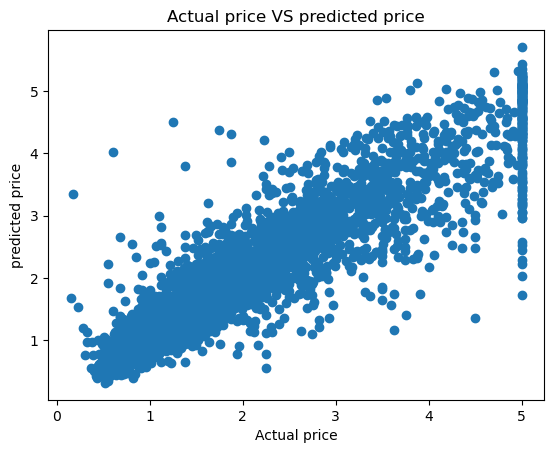

In [26]:
plt.scatter(y_test, y_predict)
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual price VS predicted price')
plt.show()